In [1]:
# | default_exp euclid.mask

# This scripts performs the following on skypatch image for noise calculation

> 1- Masks sources in a Euclid image prior to ICL measurement.
> 
> 2- Creates a coadded YJH image and constructs a measurement mask to be used in following processes.
> 
> 3- Uses the measurement mask and calculates backgrounds for H, J, Y and YJH images separately
> 
> 4- Those backgrounds then are passed to create background subtracted images for each band
> 
> 5- The background subtracted images then are used in measuring the noise curves from.

In [2]:
# | exporti

from pathlib import Path

import numpy as np
import pandas as pd

import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

from nicl.mask import (
    create_bcg_mask,
    create_icl_mask,
    create_faint_mask,
    create_object_mask,
)
from nicl.utilities import (
    calc_sb_threshold as _calc_sb_threshold,
    get_pixel_scale,
    sb_to_adu,
)

In [3]:
# | hide

import logging

import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.nddata import CCDData

from nicl.euclid.utilities import default_data_path
from nicl.background import get_background, plot_background
from nicl.main import configure_logging
from nicl.mask import (
    fast_mask,
    plot_mask,
)

In [4]:
# | exporti

plt.style.use("nicl.euclid.v1nicl")

In [5]:
# | export

def calc_sb_threshold(
    z,  # cluster redshift
    filter,  # Euclid filter: VIS, Y, J or H
):
    """Determine the ICL surface brightness threshold for a given redshift and Euclid filter."""
    filter = filter.replace("NIR_", "")
    filter = f"Euclid-{filter}.ecsv"
    return _calc_sb_threshold(z, filter)

In [6]:
# TUTKU'S PARAMETERS
ICL_NSIGMA = 2.0
ICL_SMOOTH_SIGMA = 50.0
ICL_BKG_BOX_SIZE = 300
ICL_BKG_FILTER_SIZE = 3
ICL_DILATION_RADIUS = 70.0
ICL_MEDIAN_FILTER = True
REGULAR_DETECTION_PARAMS = {
    "nsigma": 3.0,
    "background": 0.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 32,
    "contrast": 0.01,
    "bkg_box_size": 200,
    "bkg_filter_size": 3,
}
REGULAR_GROWTH = 0.5
FAINT_DETECTION_PARAMS = {
    "nsigma": 2.0,
    "smooth_sigma": 1.0,
    "npixels": 5,
    "nlevels": 128,
    "contrast": 0.001,
}
FAINT_GROWTH = 0.25
FAINT_BKG_SIGMA = 50.0
NIR_STACK_BKG_BOX_SIZE = 500
NIR_STACK_BKG_FILTER_SIZE = 3

# ICL_NSIGMA = 2.0
# ICL_SMOOTH_SIGMA = 50.0
# ICL_BKG_BOX_SIZE = 500
# ICL_BKG_FILTER_SIZE = 3
# ICL_DILATION_RADIUS = 50.0
# ICL_MEDIAN_FILTER = True
# REGULAR_DETECTION_PARAMS = {
#     "nsigma": 3.0,
#     "background": 0.0,
#     "smooth_sigma": 1.0,
#     "npixels": 5,
#     "nlevels": 32,
#     "contrast": 0.01,
#     "bkg_box_size": 200,
#     "bkg_filter_size": 3,
# }
# REGULAR_GROWTH = 0.5
# FAINT_DETECTION_PARAMS = {
#     "nsigma": 2.0,
#     "smooth_sigma": 1.0,
#     "npixels": 5,
#     "nlevels": 128,
#     "contrast": 0.001,
# }
# FAINT_GROWTH = 0.25
# FAINT_BKG_SIGMA = 50.0
# NIR_STACK_BKG_BOX_SIZE = 500
# NIR_STACK_BKG_FILTER_SIZE = 3

In [7]:
# | export

def create_masks(
    image,  # the image to mask, with bad pixels set to NaN, as a CCDImage or filename
    *,  # the following parameters must be provided as keyword arguments if required
    z=None,  # the cluster redshift for the BCG mask; if None then returned BCG mask is None
    filter=None,  # the filter name for the BCG mask; if None then returned BCG mask is None
    centre_pos=None,  # the position of the BCG/cluster centre; set to False for a non-cluster image
    make_faint_mask=True,  # whether to create a separate object mask in the ICL region
    zeropoint="ZPAB",  # the zeropoint, either as a header keyword or numeric value
):
    """Create BCG, ICL, object and faint masks with default settings for Euclid data.

    These default settings are to be refined.
    """
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")  # unit does not matter
        print(image)
        
    # === Bad pixels ===
    badpixel_mask = ~np.isfinite(image)
    # === BCG ===
    if centre_pos is not False and z is not None and filter is not None:
        sb_threshold = calc_sb_threshold(z, filter)
        if isinstance(zeropoint, str):
            zp = image.header[zeropoint] * u.ABmag
        else:
            zp = zeropoint * u.ABmag
        sb_adu_threshold = sb_to_adu(sb_threshold, get_pixel_scale(image), zp)
        bcg_mask = create_bcg_mask(
            image.data,
            sb_threshold=sb_adu_threshold,
            centre_pos=centre_pos,
            wcs=image.wcs,
        )
    else:
        bcg_mask = None
    # === ICL ===
    if centre_pos is not False:
        icl_mask, _ = create_icl_mask(
            image.data,
            centre_pos=centre_pos,
            wcs=image.wcs,
            nsigma=ICL_NSIGMA,
            smooth_sigma=ICL_SMOOTH_SIGMA,
            bkg_box_size=ICL_BKG_BOX_SIZE,
            bkg_filter_size=ICL_BKG_FILTER_SIZE,
            dilation_radius=ICL_DILATION_RADIUS,
            median_filter=ICL_MEDIAN_FILTER,
        )
    else:
        icl_mask = None
    # === Regular objects ===
    if make_faint_mask:
        # In this case, we exclude objects under the ICL mask,
        # as these will be included in the faint mask
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_mask=icl_mask,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    else:
        # In this case, we only exclude the object at the central position
        object_mask, bkg, threshold, centre_mask = create_object_mask(
            image.data,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=REGULAR_GROWTH,
            detection_params=REGULAR_DETECTION_PARAMS,
        )
    # === Faint objects (under ICL) ===
    if centre_pos is not False and make_faint_mask:
        faint_mask, faint_bkg, faint_threshold = create_faint_mask(
            image.data,
            include_mask=centre_mask,
            exclude_position=centre_pos,
            wcs=image.wcs,
            growth=FAINT_GROWTH,
            detection_params=FAINT_DETECTION_PARAMS,
            bkg_sigma=FAINT_BKG_SIGMA,
        )
    else:
        faint_mask = None
    output_masks = {
        "badpixel": badpixel_mask,
        "bcg": bcg_mask,
        "icl": icl_mask,
        "object": object_mask,
        "faint": faint_mask,
    }
    return output_masks

In [8]:
def save_masks(
    masks,  # Dictionary of masks returned by create_masks
    output_dir=None,  # Path to save the masks
    label=None,
):
    """Save all masks produced by create_masks to disk."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = f"{label}_" if label else ""
    for mask_name, mask in masks.items():
        if mask is not None:
            mask = mask.astype(np.uint8)
            output_fn = output_dir / f"{prefix}{mask_name}_mask.fits"
            fits.writeto(output_fn, mask)

In [9]:
# | export


def make_mask_plot(image, masks, output_dir=None, label=None):
    for mask_name, mask in masks.items():
        plot_mask(image, mask, detail=True)
        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            prefix = f"{label}_" if label else ""
            plt.savefig(output_dir / f"{prefix}{mask_name}_mask.pdf")
            plt.close()

In [78]:
# | export

### updated nir_mask function, changed get_fitsdata to CCDDATA because we require the image.wcs in masksking procedures. The masking will place bkgsub images to a temp folder and use within stacking code. Then will get rid of them
### additionally, included centre_pos parameter to both nir and vis masks to be able to create a combined nir mask for skypatch.

def stack_nir_bands(H_filename, J_filename, Y_filename, output_dir=None, label=None):
    """Stack NIR images and optionally save to disk. Returns a CCDData object."""
    logger = logging.getLogger(__name__)
    logger.info(f"Stacking images: {H_filename}, {J_filename}, {Y_filename}")
    
    # Reading images as CCDData to preserve WCS
    H = CCDData.read(H_filename, unit="adu")
    J = CCDData.read(J_filename, unit="adu")
    Y = CCDData.read(Y_filename, unit="adu")

    images = {"H": H.data, "J": J.data, "Y": Y.data}
    masks = {band: ~np.isfinite(images[band]) for band in ["H", "J", "Y"]}
    global_mask = masks["H"] | masks["J"] | masks["Y"]
    
    for band in ["H", "J", "Y"]:
        images[band][global_mask] = np.nan

    bandwidth = {"H": 499.9, "J": 399.4, "Y": 262.7}
    total_bandwidth = sum(bandwidth.values())
    
    combined_image = (
        (images["H"] * bandwidth["H"])
        + (images["J"] * bandwidth["J"])
        + (images["Y"] * bandwidth["Y"])
    ) / total_bandwidth

    logger.debug(
        f"Combined Image: Min={np.nanmin(combined_image)}, Max={np.nanmax(combined_image)}, NaN Count={np.isnan(combined_image).sum()}"
    )

    # Using H-band WCS as reference
    combined_ccd = CCDData(combined_image, unit="adu", wcs=H.wcs)

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = combined_ccd.wcs.to_header()
        fits.writeto(
            output_dir / f"{prefix}HJY_combined.fits",
            combined_ccd.data,
            header=header,
            overwrite=True,
        )

    return combined_ccd
    

def create_combined_nir_mask(
    H_filename, J_filename, Y_filename, output_dir=None, label=None, centre_pos=None, redshift=None
):
    """Create a combined NIR mask for use when measuring ICL."""

    filenames = {"H": H_filename, "J": J_filename, "Y": Y_filename}
    images = {}

    for band in ["H", "J", "Y"]:
        image = CCDData.read(filenames[band], unit="adu")
        m = create_masks(image, make_faint_mask=False, centre_pos=centre_pos, z=redshift)

        if centre_pos is not False:
            mask_for_background = m["badpixel"] | m["icl"] | m["object"]
        else:
            mask_for_background = m["badpixel"] | m["object"]

        bkg = get_background(
            image.data,
            mask=mask_for_background,
            box_size=NIR_STACK_BKG_BOX_SIZE,
            filter_size=NIR_STACK_BKG_FILTER_SIZE,
        )

        image_bkg_sub = image.data - bkg.background
        images[band] = image_bkg_sub

        # Saving temp background-subtracted image
        temp_filename = f"_temp_bkgsub_{band}.fits"
        temp_ccd = CCDData(image_bkg_sub, unit="adu", wcs=image.wcs)
        temp_ccd.write(temp_filename, overwrite=True)
        filenames[band] = temp_filename

    # Now pass temp files to stacking function
    print("Proceeding to stack_nir_bands...")
    combined_ccd = stack_nir_bands(filenames["H"], filenames["J"], filenames["Y"], output_dir=None, label=None)
    print("stack_nir_bands is complete...")
    if output_dir:
        fits.writeto(
            output_dir / f"{prefix}NIR_YJH_COADDED.fits",
            combined_ccd.data,
            header=header,
            overwrite=True
        )
        print('Coadded image is saved.')
        
    print("Masking the coadded image...")
    masks = create_masks(combined_ccd, centre_pos=centre_pos, z=redshift)

    if centre_pos is not False:
        mask_for_background = masks["badpixel"] | masks["icl"] | masks["object"]
    else:
        mask_for_background = masks["badpixel"] | masks["object"]
        
    faint_mask = masks["faint"] if masks["faint"] is not None else np.zeros_like(masks["object"], dtype=bool)
    mask_for_measurement = masks["badpixel"] | masks["object"] | faint_mask
    
    print("Masks are generated...")
    
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = combined_ccd.wcs.to_header()

        fits.writeto(
            output_dir / f"{prefix}NIR_background_mask.fits",
            mask_for_background.astype("uint8"),
            header=header,
            overwrite=True,
        )
        fits.writeto(
            output_dir / f"{prefix}NIR_measurement_mask.fits",
            mask_for_measurement.astype("uint8"),
            header=header,
            overwrite=True,
        )
        

    # Cleanup temp files
    for band in ["H", "J", "Y"]:
        temp_file = filenames[band]
        if "_temp_bkgsub_" in temp_file and Path(temp_file).exists():
            Path(temp_file).unlink()

    return mask_for_background, mask_for_measurement, combined_ccd.data
    

def create_vis_mask(VIS_filename, output_dir=None, label=None, centre_pos=None, redshift=None):
    """Create a VIS mask for use when measuring ICL."""
    image = CCDData.read(VIS_filename, unit="adu")
    masks = create_masks(image, centre_pos=centre_pos, z=redshift)

    if centre_pos is not False:
        mask_for_background = masks["badpixel"] | masks["icl"] | masks["object"]
    else:
        mask_for_background = masks["badpixel"] | masks["object"]
        
    faint_mask = masks["faint"] if masks["faint"] is not None else np.zeros_like(masks["object"], dtype=bool)
    mask_for_measurement = masks["badpixel"] | masks["object"] | faint_mask

    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{label}_" if label else ""
        header = image.wcs.to_header()

        fits.writeto(
            output_dir / f"{prefix}VIS_background_mask.fits",
            mask_for_background.astype("uint8"),
            header=header,
            overwrite=True,
        )
        fits.writeto(
            output_dir / f"{prefix}VIS_measurement_mask.fits",
            mask_for_measurement.astype("uint8"),
            header=header,
            overwrite=True,
        )

    return mask_for_measurement, mask_for_background



    

## Examples applying `nicl.mask` functions to Euclid data

In [76]:
configure_logging(name="nicl.euclid.mask", level="DEBUG")
configure_logging(name="nicl.mask", level="DEBUG")

<Logger nicl.mask (DEBUG)>

# Testing the stacking and nir masking with small cutout from skypatch


In [15]:
# dataDir = '/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/sky_patch/'
# outputDir = '/home/ppztk1/Erosita/Outputs_Clusters/sky_patch_cut/'

# def cut_fits_image(input_path, output_path, center=None, size=(2000, 2000)):
#     """Cutout a square region from a FITS image."""
#     ccd = CCDData.read(input_path, unit="adu")
#     data = ccd.data
#     header = ccd.header
#     wcs = ccd.wcs

#     ny, nx = data.shape

#     if center is None:
#         cx, cy = nx // 2, ny // 2  # center of image
#     else:
#         cx, cy = center

#     half_x, half_y = size[0] // 2, size[1] // 2
#     x_start, x_end = cx - half_x, cx + half_x
#     y_start, y_end = cy - half_y, cy + half_y

#     cutout_data = data[y_start:y_end, x_start:x_end]

#     # Adjust WCS reference pixel
#     wcs.wcs.crpix[0] -= x_start
#     wcs.wcs.crpix[1] -= y_start
#     cutout_header = wcs.to_header()

#     fits.writeto(output_path, cutout_data, header=cutout_header, overwrite=True)
#     print(f"Saved cutout to {output_path}")

# 
# cutDir = outputDir
# Path(cutDir).mkdir(exist_ok=True)

# cut_fits_image(dataDir + 'EUC_NIR_W-STK_H-sky_patch.fits', cutDir + 'cut_H.fits')
# cut_fits_image(dataDir + 'EUC_NIR_W-STK_J-sky_patch.fits', cutDir + 'cut_J.fits')
# cut_fits_image(dataDir + 'EUC_NIR_W-STK_Y-sky_patch.fits', cutDir + 'cut_Y.fits')

# H_image = cutDir + 'cut_H.fits'
# J_image = cutDir + 'cut_J.fits'
# Y_image = cutDir + 'cut_Y.fits'

# bkg_mask, meas_mask, combined_im = create_combined_nir_mask(
#     H_image, J_image, Y_image, centre_pos=False, label='Skypatch', output_dir=outputDir
# )
# print('Done')


In [14]:
# Construct coadded image and measurement masks...
profileDir = '/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/'
outputDir = '/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/'
dataDir = '/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/sky_patch/'

H_image = dataDir + 'EUC_NIR_W-STK_H-sky_patch.fits'
J_image = dataDir + 'EUC_NIR_W-STK_J-sky_patch.fits'
Y_image = dataDir + 'EUC_NIR_W-STK_Y-sky_patch.fits'

bkg_mask, meas_mask, combined_im = create_combined_nir_mask(H_image, J_image, Y_image, centre_pos=False, label='Skypatch', output_dir=outputDir)
print('Created NIR masks!')

VIS_image = dataDir + 'EUC_VIS_SWL-STK-sky_patch.fits'
bkg_mask_vis, meas_mask_vis = create_vis_mask(VIS_image, centre_pos=False, label='Skypatch', output_dir=outputDir)

print('Created VIS masks!')

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-04-15 12:31:35 - nicl.mask.create_object_mask - INFO - Creating object mask
2025-04-15 12:31:35 - nicl.mask.create_object_mask - INFO - Estimating background and detection threshold
2025-04-15 12:34:19 - nicl.mask.create_object_mask - INFO - Average 3.0 sigma threshold is 0.06155
2025-04-15 12:34:19 - nicl.mask.create_object_mask - INFO - Smoothing image
2025-04-15 12:35:24 - nicl.mask.create_object_mask - INFO - Detecting sources
2025-04-15 12:35:58 - nicl.mask.create_object_mask - INFO - Deblending 260795 sources
2025-04-15 12:42:46 - nicl.mask.create_object_mask - INFO - Object mask contains 276406 sources
2025-04-15 12:43:00 - nicl.mask.create_object_mask - INFO - Dilating mask
2025-04-15 12:43:00 - nicl.mask.dilated_object_mask - INFO - Dilating object mask with growth factor of 0.5
2025-04-15 12:43:17 - nicl.mask.dilated_object_mask - DEBUG - current minimum size is 2 pixels
2025-04-15 12:43:20 - nicl.mask.dilated_object_mask - DEBUG - removing 86861 segments smaller than 12

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-04-15 13:02:16 - nicl.mask.create_object_mask - INFO - Creating object mask
2025-04-15 13:02:16 - nicl.mask.create_object_mask - INFO - Estimating background and detection threshold
2025-04-15 13:04:57 - nicl.mask.create_object_mask - INFO - Average 3.0 sigma threshold is 0.05988
2025-04-15 13:04:57 - nicl.mask.create_object_mask - INFO - Smoothing image
2025-04-15 13:06:05 - nicl.mask.create_object_mask - INFO - Detecting sources
2025-04-15 13:06:30 - nicl.mask.create_object_mask - INFO - Deblending 243700 sources
2025-04-15 13:12:33 - nicl.mask.create_object_mask - INFO - Object mask contains 256710 sources
2025-04-15 13:12:45 - nicl.mask.create_object_mask - INFO - Dilating mask
2025-04-15 13:12:45 - nicl.mask.dilated_object_mask - INFO - Dilating object mask with growth factor of 0.5
2025-04-15 13:13:01 - nicl.mask.dilated_object_mask - DEBUG - current minimum size is 2 pixels
2025-04-15 13:13:02 - nicl.mask.dilated_object_mask - DEBUG - removing 87000 segments smaller than 12

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-04-15 13:31:44 - nicl.mask.create_object_mask - INFO - Creating object mask
2025-04-15 13:31:44 - nicl.mask.create_object_mask - INFO - Estimating background and detection threshold
2025-04-15 13:34:23 - nicl.mask.create_object_mask - INFO - Average 3.0 sigma threshold is 0.06782
2025-04-15 13:34:23 - nicl.mask.create_object_mask - INFO - Smoothing image
2025-04-15 13:35:28 - nicl.mask.create_object_mask - INFO - Detecting sources
2025-04-15 13:35:52 - nicl.mask.create_object_mask - INFO - Deblending 192898 sources
2025-04-15 13:40:36 - nicl.mask.create_object_mask - INFO - Object mask contains 201532 sources
2025-04-15 13:40:47 - nicl.mask.create_object_mask - INFO - Dilating mask
2025-04-15 13:40:47 - nicl.mask.dilated_object_mask - INFO - Dilating object mask with growth factor of 0.5
2025-04-15 13:41:02 - nicl.mask.dilated_object_mask - DEBUG - current minimum size is 2 pixels
2025-04-15 13:41:04 - nicl.mask.dilated_object_mask - DEBUG - removing 71572 segments smaller than 12

Proceeding to stack_nir_bands...
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
stack_nir_bands is complete...
Masking the coadded image...


2025-04-15 14:00:51 - nicl.mask.create_object_mask - INFO - Creating object mask
2025-04-15 14:00:51 - nicl.mask.create_object_mask - INFO - Estimating background and detection threshold
2025-04-15 14:03:22 - nicl.mask.create_object_mask - INFO - Average 3.0 sigma threshold is 0.03841
2025-04-15 14:03:22 - nicl.mask.create_object_mask - INFO - Smoothing image
2025-04-15 14:04:19 - nicl.mask.create_object_mask - INFO - Detecting sources
2025-04-15 14:04:39 - nicl.mask.create_object_mask - INFO - Deblending 329595 sources
2025-04-15 14:13:15 - nicl.mask.create_object_mask - INFO - Object mask contains 352945 sources
2025-04-15 14:13:24 - nicl.mask.create_object_mask - INFO - Dilating mask
2025-04-15 14:13:24 - nicl.mask.dilated_object_mask - INFO - Dilating object mask with growth factor of 0.5
2025-04-15 14:13:37 - nicl.mask.dilated_object_mask - DEBUG - current minimum size is 2 pixels
2025-04-15 14:13:39 - nicl.mask.dilated_object_mask - DEBUG - removing 113965 segments smaller than 1

Masks are generated...
Done


In [ ]:
# Construct coadded image and measurement masks...
profileDir = '/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/'
outputDir = '/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/'
dataDir = '/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/sky_patch/'

VIS_image = dataDir + 'EUC_VIS_SWL-STK-sky_patch.fits'
bkg_mask_vis, meas_mask_vis = create_vis_mask(VIS_image, centre_pos=False, label='Skypatch', output_dir=outputDir)

print('Created VIS masks!')

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


2025-04-15 17:59:09 - nicl.mask.create_object_mask - INFO - Creating object mask
2025-04-15 17:59:09 - nicl.mask.create_object_mask - INFO - Estimating background and detection threshold
2025-04-15 18:01:49 - nicl.mask.create_object_mask - INFO - Average 3.0 sigma threshold is 0.01686
2025-04-15 18:01:49 - nicl.mask.create_object_mask - INFO - Smoothing image
2025-04-15 18:02:50 - nicl.mask.create_object_mask - INFO - Detecting sources
2025-04-15 18:03:19 - nicl.mask.create_object_mask - INFO - Deblending 344484 sources
2025-04-15 18:11:49 - nicl.mask.create_object_mask - INFO - Object mask contains 362171 sources
2025-04-15 18:12:06 - nicl.mask.create_object_mask - INFO - Dilating mask
2025-04-15 18:12:06 - nicl.mask.dilated_object_mask - INFO - Dilating object mask with growth factor of 0.5
2025-04-15 18:12:26 - nicl.mask.dilated_object_mask - DEBUG - current minimum size is 2 pixels
2025-04-15 18:12:28 - nicl.mask.dilated_object_mask - DEBUG - removing 156809 segments smaller than 1

# Below, function calculates the noise measuremtns using the measurement mask constructed above. 

In [ ]:
from photutils.aperture import CircularAnnulus
from photutils.utils import calc_total_error
from matplotlib.colors import Normalize
from scipy.stats import median_abs_deviation
from astropy.stats import sigma_clip
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.nddata import CCDData


# New cleaning function...

def create_bkgsub_images(
    image_paths,
    measurement_mask_path,
    output_background_dir,
    temp_cleaned_dir,
    centre_pos=False,
    label= None,
    clean_nans=False
):
    """
    Loads images, applies the measurement mask to estimate background,
    saves the background maps, and writes cleaned background-subtracted images with NaNs set to 99.
    """
    Path(output_background_dir).mkdir(parents=True, exist_ok=True)
    Path(temp_cleaned_dir).mkdir(parents=True, exist_ok=True)

    measurement_mask = fits.getdata(measurement_mask_path).astype(bool)

    filenames_cleaned = {}

    for band, image_path in image_paths.items():
        image = CCDData.read(image_path, unit="adu")

        bkg = get_background(
            image.data,
            mask=measurement_mask,
            box_size=NIR_STACK_BKG_BOX_SIZE,
            filter_size=NIR_STACK_BKG_FILTER_SIZE,
        )

        # Save background
        bkg_filename = Path(output_background_dir) / f"{label}_bkg.fits"
        
        fits.writeto(
            bkg_filename,
            bkg.background,
            header=image.wcs.to_header(),
            overwrite=True
        )

        # Subtract background and clean NaNs
        image_bkg_sub = image.data - bkg.background

        if clean_nans:
            image_bkg_sub = np.where(np.isfinite(image_bkg_sub), image_bkg_sub, 99)
            cleaned_filename = Path(temp_cleaned_dir) / f"{label}_cleaned_bkgsub.fits"
            
        else:
            cleaned_filename = Path(temp_cleaned_dir) / f"{label}_bkgsub.fits"
        
        cleaned_ccd = CCDData(image_bkg_sub, unit="adu", wcs=image.wcs)
        cleaned_ccd.write(cleaned_filename, overwrite=True)

        filenames_cleaned[band] = str(cleaned_filename)

    return filenames_cleaned


In [65]:
def measure_noise_in_circular_annuli(
    image_path, 
    object_mask_path, 
    profile_path, 
    hdul_index=0, 
    pixelscale=0.3,
    core_mask_path=None, 
    rad_limit_annulus=None, 
    verbose=None, 
    num_points=50,
    output_path=None, 
    show_diagnostic_plots=True, 
    save_diagnostics=False, 
    show_annuli=False, 
    zp=23.9,
):
    profiles = sorted(glob.glob(str(profile_path)))
    print(f'Profile: {profiles}')

    df_dict = {}
    for profile in profiles:
        filekey = profile.split('/')[-1].split('_')
        clusterid = filekey[0] + '_' + filekey[1]
        boxsize = (filekey[5].split('.')[0]) if len(filekey) > 4 else 0
        gs = f"_{filekey[filekey.index('gscale') + 1]}" if "gscale" in filekey else ""
        label = f"{clusterid}_{boxsize}{gs}"
        df_dict[label] = pd.read_csv(profile, skiprows=1)
        print(f'label is: {label}...')

    image_ccd = CCDData.read(image_path, unit="adu", hdu=hdul_index)
    image = image_ccd.data
    object_mask = fits.getdata(object_mask_path).astype(bool)
    masked_image = np.where(object_mask, np.nan, image)
    print(f'Masked image is created...')

    prof = df_dict[label]
    prof['R'] = prof['R'] / pixelscale
    if rad_limit_annulus:
        prof = prof[prof['R'] < rad_limit_annulus]
    selected_annuli = sorted(set(prof['R'].values))
    first_radius = selected_annuli[0] if selected_annuli else 0
    r_max = max(selected_annuli) if selected_annuli else 0

    image_height, image_width = image.shape
    valid_y, valid_x = np.where(~object_mask)
    valid_points = np.column_stack((valid_x, valid_y))
    valid_points = valid_points[
        (valid_points[:, 0] > r_max) &
        (valid_points[:, 0] < image_width - r_max) &
        (valid_points[:, 1] > r_max) &
        (valid_points[:, 1] < image_height - r_max)
    ]

    flux_stats = []
    final_selected_points = []

    while len(final_selected_points) < num_points and valid_points.size > 0:
        x, y = valid_points[np.random.choice(len(valid_points))]
        x += np.random.uniform(-0.5, 0.5)
        y += np.random.uniform(-0.5, 0.5)

        annulus = CircularAnnulus((x, y), r_in=0.5, r_out=first_radius)
        test = annulus.to_mask(method='exact').multiply(masked_image)
        if np.count_nonzero(np.isfinite(test) & (test != 0)) == 0:
            continue

        final_selected_points.append((x, y))
        print(f'The noise profile is being extracted around point: {x:.1f}, {y:.1f}')

        for i in range(len(selected_annuli) - 1):
            r_in, r_out = selected_annuli[i], selected_annuli[i + 1]
            ann = CircularAnnulus((x, y), r_in, r_out).to_mask(method='center').to_image(masked_image.shape)
            values = masked_image[np.isfinite(masked_image) & (ann > 0)]

            stats = {
                'Centre_pixel': (x, y),
                'Inner_Radius_pix': r_in,
                'Outer_Radius_pix': r_out,
                'Inner_Radius_arcsec': r_in * pixelscale,
                'Outer_Radius_arcsec': r_out * pixelscale,
                'SMA_annulus_centre_pix': (r_in + r_out) / 2,
                'SMA_annulus_centre_arcsec': ((r_in + r_out) * pixelscale) / 2
            }

            if len(values) == 0:
                stats.update({key: np.nan for key in [
                    'Mean_flux_annulus', 'Median_flux_annulus', 'Std_flux_annulus',
                    'Clipped_mean_flux_annulus', 'Clipped_median_flux_annulus',
                    'Clipped_Std_flux_annulus', 'Total_valid_pix_annulus',
                ]})
            else:
                clipped = sigma_clip(values, sigma=3, cenfunc='median', maxiters=5)
                clipped_values = clipped.data[~clipped.mask]
                stats.update({
                    'Mean_flux_annulus': np.nanmean(values) / pixelscale**2,
                    'Median_flux_annulus': np.nanmedian(values) / pixelscale**2,
                    'Std_flux_annulus': np.nanstd(values) if len(values) > 1 else np.nan,
                    'Clipped_mean_flux_annulus': np.nanmean(clipped_values) / pixelscale**2,
                    'Clipped_median_flux_annulus': np.nanmedian(clipped_values) / pixelscale**2,
                    'Clipped_Std_flux_annulus': np.nanstd(clipped_values) if len(clipped_values) > 1 else np.nan,
                    'Total_valid_pix_annulus': len(values),
                })

            flux_stats.append(stats)

    flux_stats_df = pd.DataFrame(flux_stats)

    # Background subtraction
    flux_grouped = flux_stats_df.groupby('Centre_pixel')
    flux_combined = []
    for centre, group in flux_grouped:
        bkg_region = group[group['SMA_annulus_centre_arcsec'] > 300]
        if bkg_region.empty:
            continue
        bkg = np.nanmean(bkg_region['Clipped_median_flux_annulus'])
        noise = np.nanstd(bkg_region['Clipped_median_flux_annulus'])
        group = group.copy()
        group['bkg_sub_flux'] = group['Clipped_median_flux_annulus'] - bkg
        group['bkg_noise'] = 3 * noise
        flux_combined.append(group)

    extended_measurement_table = pd.concat(flux_combined, ignore_index=True)

    # Median Absolute Deviation calculation as noise
    mad_group = extended_measurement_table.groupby('SMA_annulus_centre_arcsec')
    radii = sorted(mad_group.groups.keys())
    noise_measurements = pd.DataFrame({
        'SMA_annulus_centre_arcsec': [r * pixelscale for r in radii],
        'MAD_Median_Clipped_Flux': [median_abs_deviation(mad_group.get_group(r)['Clipped_median_flux_annulus'], scale="normal", nan_policy='omit') for r in radii],
        'MAD_Bkg_Subtracted_Flux': [median_abs_deviation(mad_group.get_group(r)['bkg_sub_flux'], scale="normal", nan_policy='omit') for r in radii],
    })

    if output_path:
        output_path = Path(output_path)
        output_path.mkdir(parents=True, exist_ok=True)
        extended_measurement_table.to_csv(output_path / f"{verbose}_noise_stats_extended_datatable.csv", index=False)
        noise_measurements.to_csv(output_path / f"{verbose}_noise_measurements.csv", index=False)

    if show_annuli and final_selected_points:
        print("Plotting the annuli overlays on the image... May take a while if your image is big, and/or if you have lots of annuli... :) ")
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(masked_image, origin='lower', cmap='gray', norm=simple_norm(masked_image, 'sqrt', percent=99))
        ax.set_title(f"Overlay of All Fitted Annuli")

        for x, y in final_selected_points:
            for i in range(len(selected_annuli) - 1):
                r_out = selected_annuli[i + 1]
                ring = plt.Circle(
                    (x, y),
                    radius=r_out,
                    edgecolor='magenta',
                    facecolor='none',
                    linewidth=0.4,
                    alpha=0.5
                )
                ax.add_patch(ring)

        ax.set_xlim(0, masked_image.shape[1])
        ax.set_ylim(0, masked_image.shape[0])
        plt.show()

    if show_diagnostic_plots:
        noise_profile_diagnostics(
            extended_measurement_table,
            verbose=verbose,
            save_plots=save_diagnostics,
            output_path=output_path,
            zp=zp
        )

    return extended_measurement_table, noise_measurements, label


# Function for diagnostic plots, which is optionally also called withing noise measurement function above...

In [66]:
def noise_profile_diagnostics(
    extended_measurement_table,
    verbose=None,
    output_path=None,
    save_plots=True,
    zp=23.9,
):
    import matplotlib.lines as mlines

    """
    Plot noise profile diagnostics: clipped flux profiles and MAD trends.

    Parameters:
    - extended_measurement_table: DataFrame with background-subtracted flux and clipped stats.
    - verbose: Label for file naming.
    - output_path: Path where measurement files and figures will be saved.
    - save_plots: Whether to save figures.
    - zp: Zeropoint used for magnitude conversion.
    """
    
    grouped = extended_measurement_table.groupby('Centre_pixel')

    def plot_profiles(ax, x, y, ylabel):
        ax.plot(x, y, marker='o', markersize=2)
        ax.hlines(0, xmin=np.min(x), xmax=np.max(x), color='k', lw=1, ls='-')
        ax.set_ylabel(ylabel, fontsize=14)
        ax.set_xlabel('Radius (arcsec)', fontsize=14)
        ax.set_ylim(-0.2, 0.2)

    # Plot: Clipped median & mean flux profiles
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    for _, group in grouped:
        plot_profiles(ax[0], group['SMA_annulus_centre_arcsec'], group['Clipped_median_flux_annulus'], 'Clipped Median Flux')
        plot_profiles(ax[1], group['SMA_annulus_centre_arcsec'], group['Clipped_mean_flux_annulus'], 'Clipped Mean Flux')
    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f'{verbose}_Median_Mean_Flux_CLIPPED.pdf')
    plt.show()

    # Plot: Background-subtracted flux profiles
    fig, ax = plt.subplots(figsize=(4, 4))
    for _, group in grouped:
        ax.plot(group['SMA_annulus_centre_arcsec'], group['bkg_sub_flux'], marker='o', markersize=2)
        ax.hlines(group['bkg_noise'].iloc[0], xmin=np.min(group['SMA_annulus_centre_arcsec']), xmax=np.max(group['SMA_annulus_centre_arcsec']), color='k', lw=1, ls='--')
    ax.hlines(0, xmin=0, xmax=np.max(extended_measurement_table['SMA_annulus_centre_arcsec']), color='k', lw=0.5, ls='-')
    ax.set_ylabel('Background-subtracted Median Flux', fontsize=14)
    ax.set_xlabel('Radius (arcsec)', fontsize=14)
    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f'{verbose}_BkgsubFlux.pdf')
    plt.show()

    # Plot: MAD profiles in flux and magnitude space
    flux_grouped_rad = extended_measurement_table.groupby('SMA_annulus_centre_arcsec')
    radii = sorted(flux_grouped_rad.groups.keys())
    
    mad_median_flux = [median_abs_deviation(flux_grouped_rad.get_group(r)['Median_flux_annulus'], scale="normal", nan_policy='omit') for r in radii]
    mad_clipped_median_flux = [median_abs_deviation(flux_grouped_rad.get_group(r)['Clipped_median_flux_annulus'], scale="normal", nan_policy='omit') for r in radii]
    mad_bkg_sub_flux = [median_abs_deviation(flux_grouped_rad.get_group(r)['bkg_sub_flux'], scale="normal", nan_policy='omit') for r in radii]

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot in flux units
    ax[0].plot(radii, np.array(mad_median_flux)*3, label='MAD of Median Flux')
    ax[0].plot(radii, np.array(mad_clipped_median_flux)*3, label='MAD of Clipped Median Flux')
    ax[0].plot(radii, np.array(mad_bkg_sub_flux)*3, label='MAD of Bkg Subtracted Flux')
    ax[0].set_ylabel('3×MAD (Flux / arcsec²)', fontsize=14)
    ax[0].set_xscale('log')
    ax[0].grid(True)
    ax[0].legend()
    ax[0].set_ylim(-0.2, 2)

    # Plot in magnitude units
    def flux_to_mag(flux): return zp - 2.5 * np.log10(flux)
    ax[1].plot(radii, flux_to_mag(np.array(mad_median_flux)*3), label='MAD of Median Flux')
    ax[1].plot(radii, flux_to_mag(np.array(mad_clipped_median_flux)*3), label='MAD of Clipped Median Flux')
    ax[1].plot(radii, flux_to_mag(np.array(mad_bkg_sub_flux)*3), label='MAD of Bkg Subtracted Flux')
    ax[1].invert_yaxis()
    ax[1].set_ylabel(r'3×MAD [mag / $\rm arcsec^2$]', fontsize=14)
    ax[1].set_xscale('log')
    ax[1].grid(True)
    ax[1].legend()

    for a in ax:
        a.set_xlabel('Radius (arcsec)', fontsize=14)

    fig.tight_layout()
    if save_plots:
        plt.savefig(Path(output_path) / f'{verbose}_MAD_profiles.pdf')
    plt.show()

    print("Finished plotting noise diagnostics.")

Processing band H
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


Profile: ['/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_H_random_field_growth_0.25.prof']
label is: cluster_H_0...
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Masked image is created...
The noise profile is being extracted around point: 7575.2, 5603.1
The noise profile is being extracted around point: 5801.9, 5685.0
The noise profile is being extracted around point: 8886.9, 9950.9
The noise profile is being extracted around point: 5863.1, 5207.7
The noise profile is being extracted around point: 12954.9, 12371.8


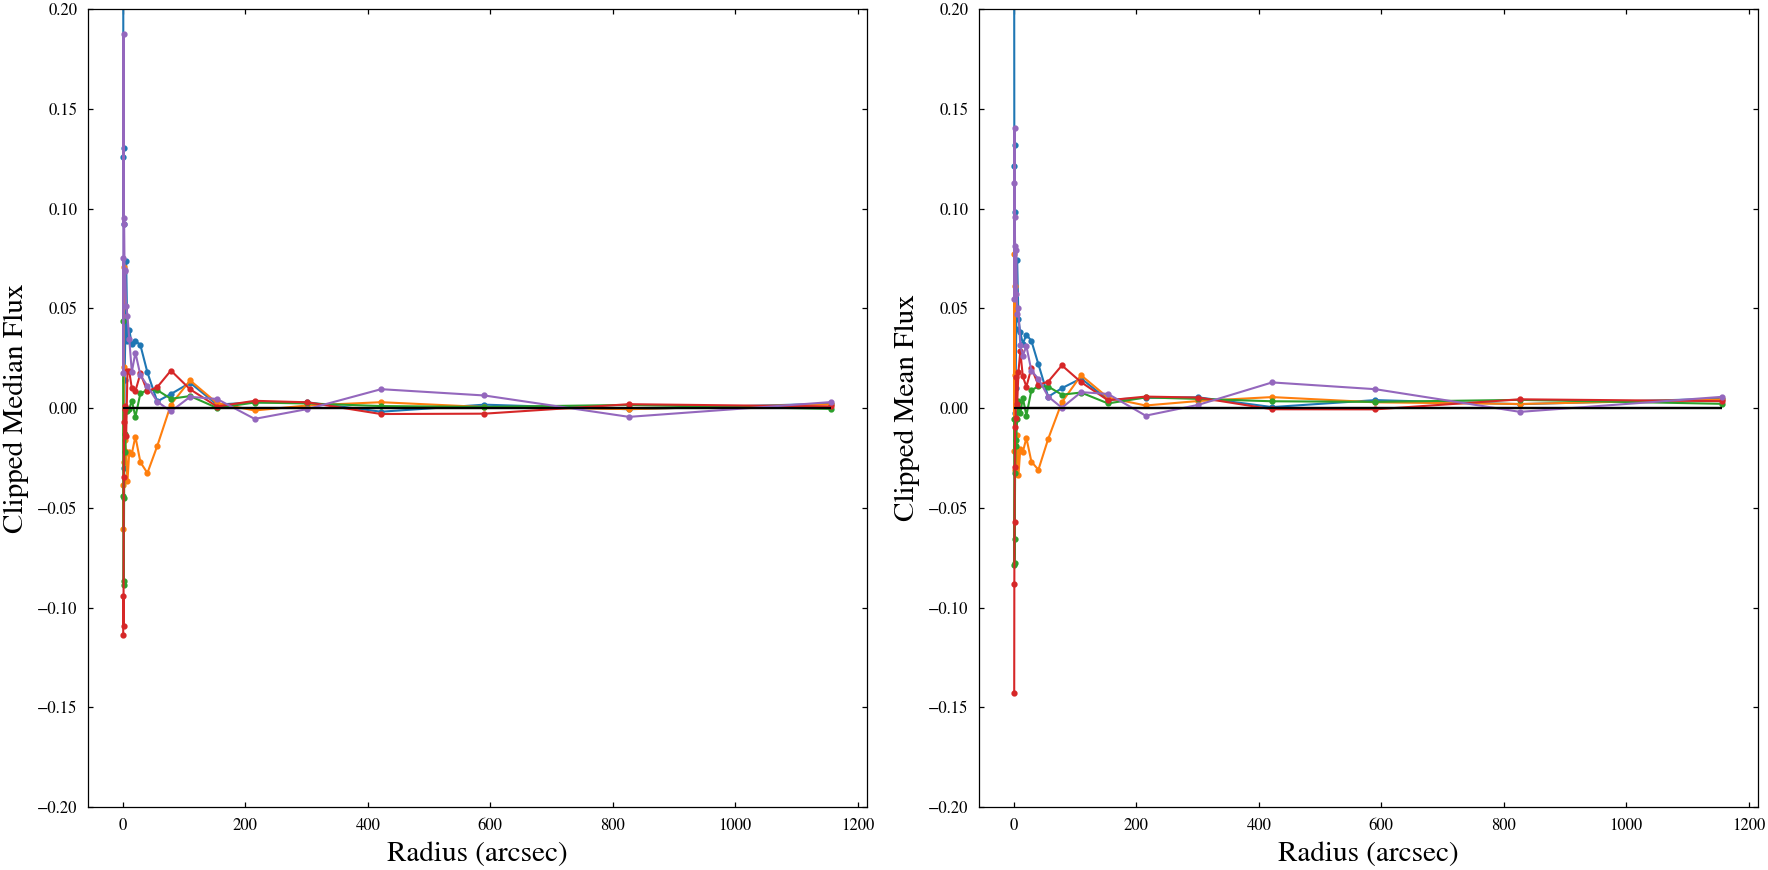

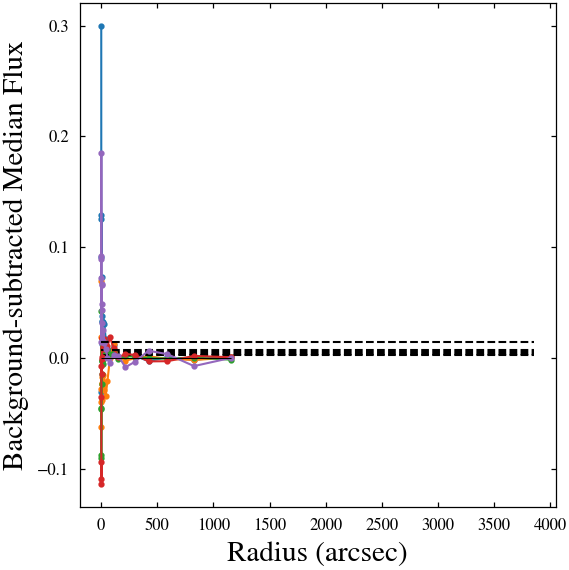

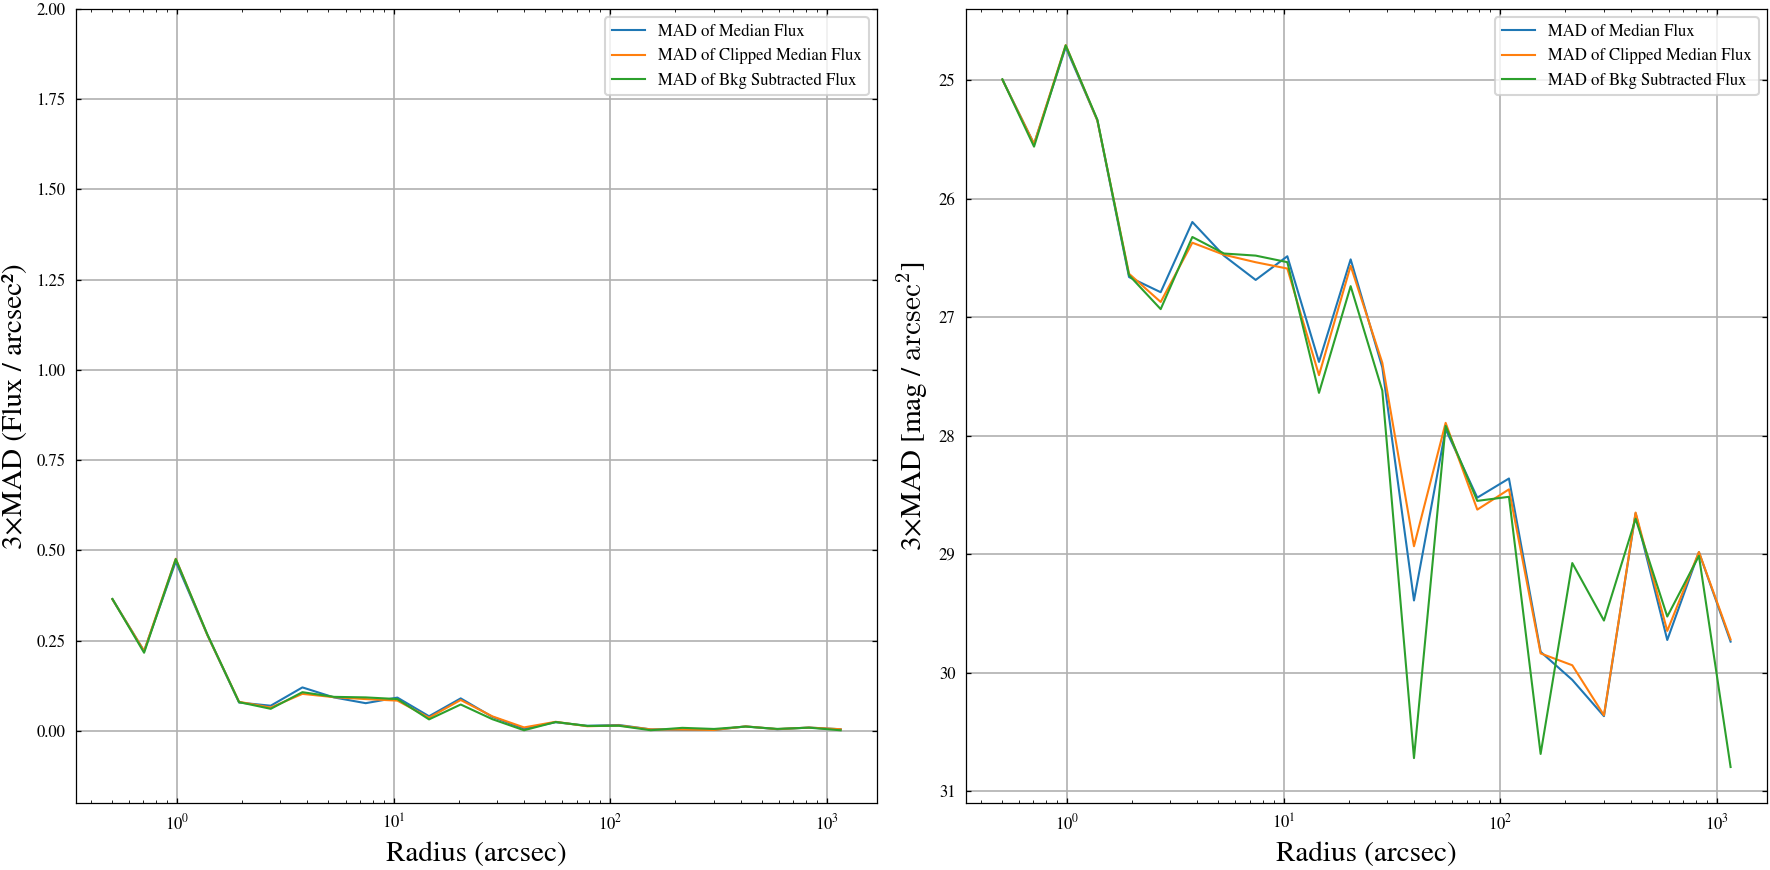

Finished plotting noise diagnostics.
Cleaned up temp file: /home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/temp_cleaned/Skypatch_H_bkgsub.fits
Processing band J
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


Profile: ['/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_H_random_field_growth_0.25.prof']
label is: cluster_H_0...
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Masked image is created...
The noise profile is being extracted around point: 9570.1, 7955.0
The noise profile is being extracted around point: 11664.0, 5717.3
The noise profile is being extracted around point: 8518.7, 13413.4
The noise profile is being extracted around point: 12882.0, 8088.6
The noise profile is being extracted around point: 12234.5, 4664.1


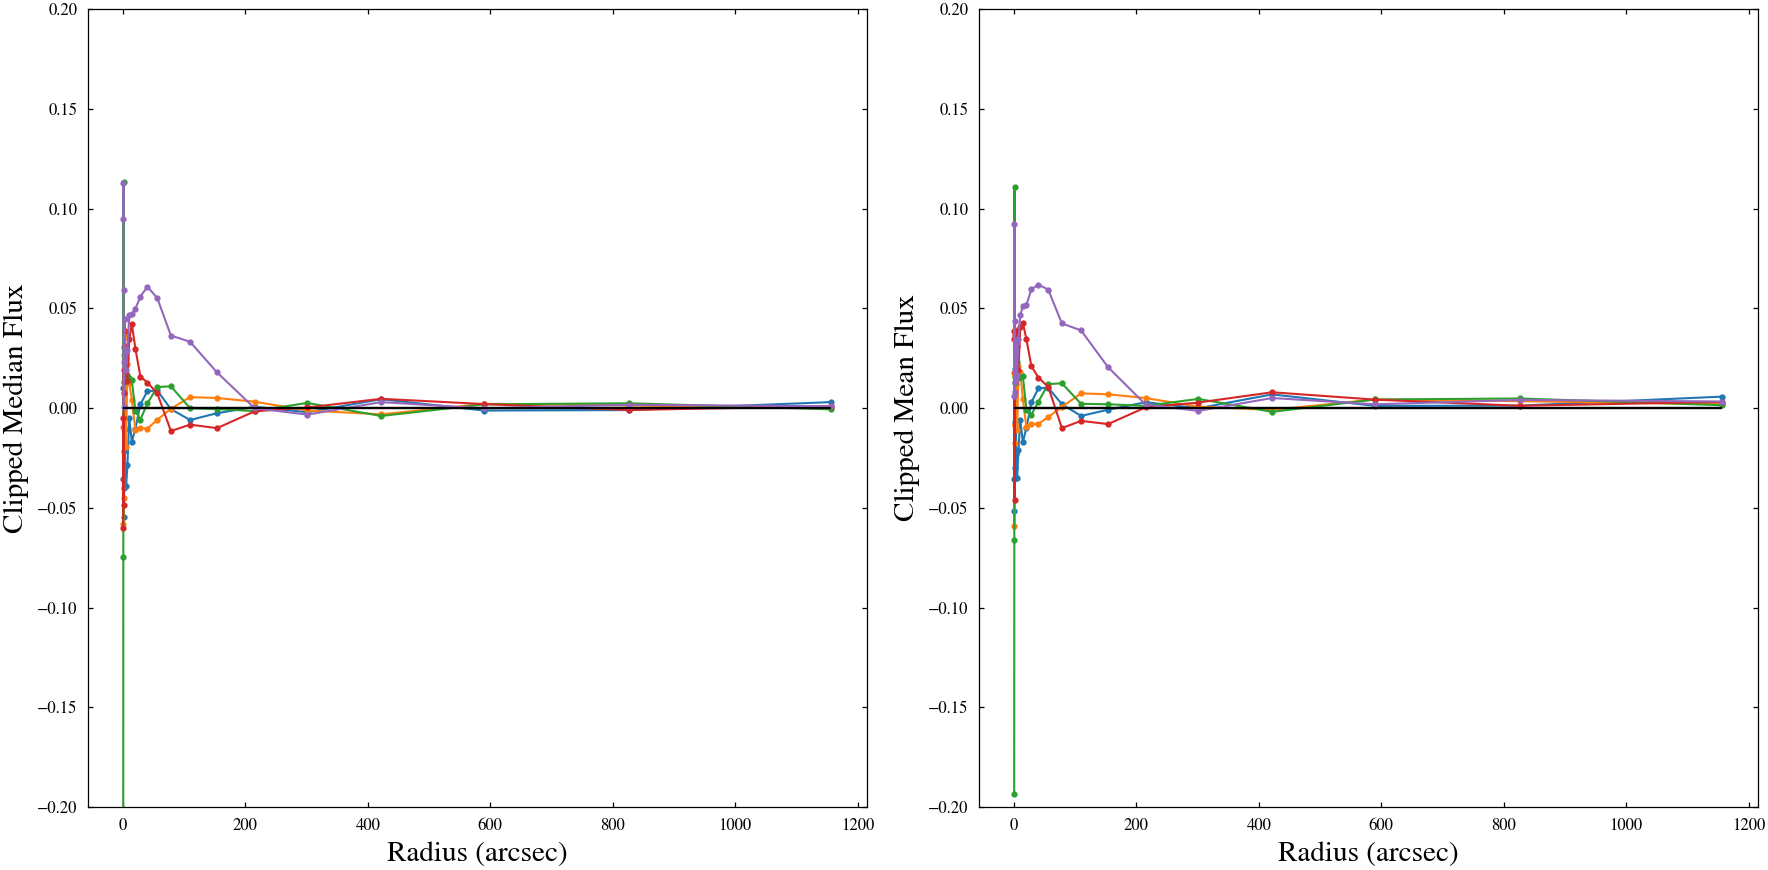

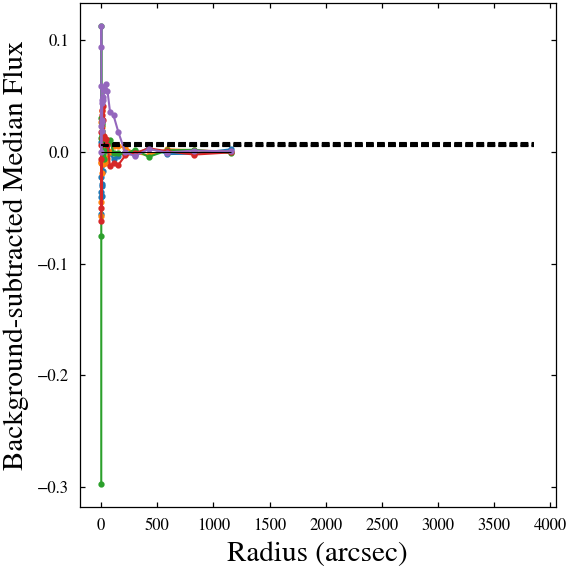

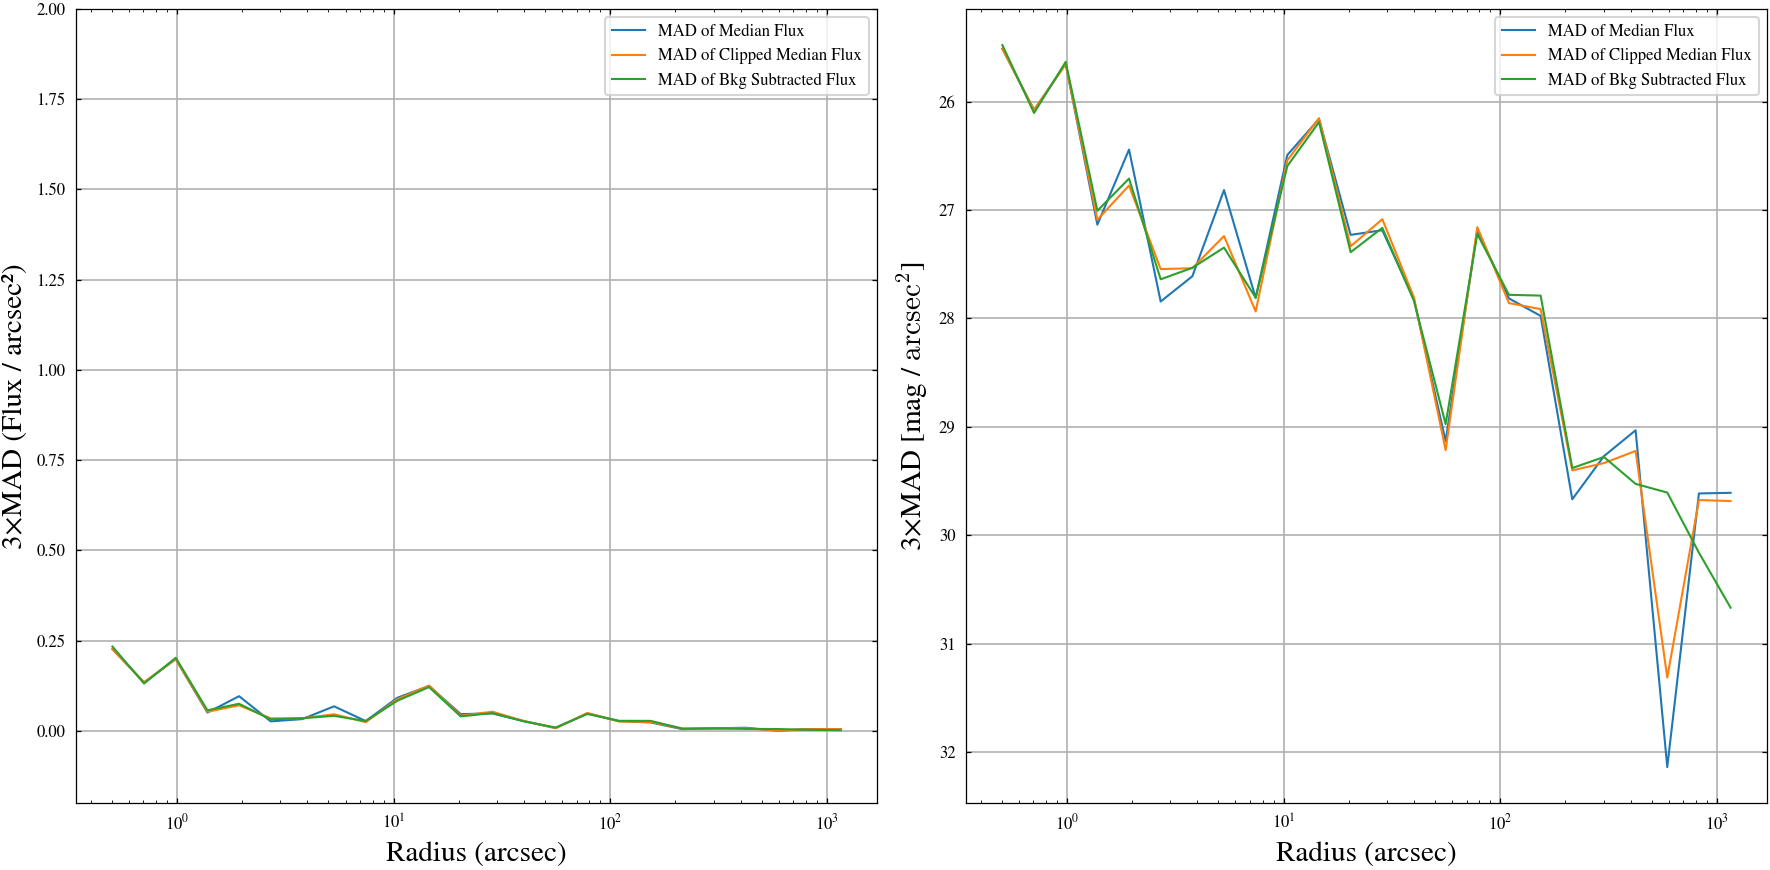

Finished plotting noise diagnostics.
Cleaned up temp file: /home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/temp_cleaned/Skypatch_J_bkgsub.fits
Processing band Y
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


Profile: ['/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/cluster_H_random_field_growth_0.25.prof']
label is: cluster_H_0...
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Masked image is created...
The noise profile is being extracted around point: 13199.0, 12310.2
The noise profile is being extracted around point: 6536.7, 8246.6
The noise profile is being extracted around point: 12366.1, 5390.1
The noise profile is being extracted around point: 7588.1, 12429.0
The noise profile is being extracted around point: 11661.2, 7230.7


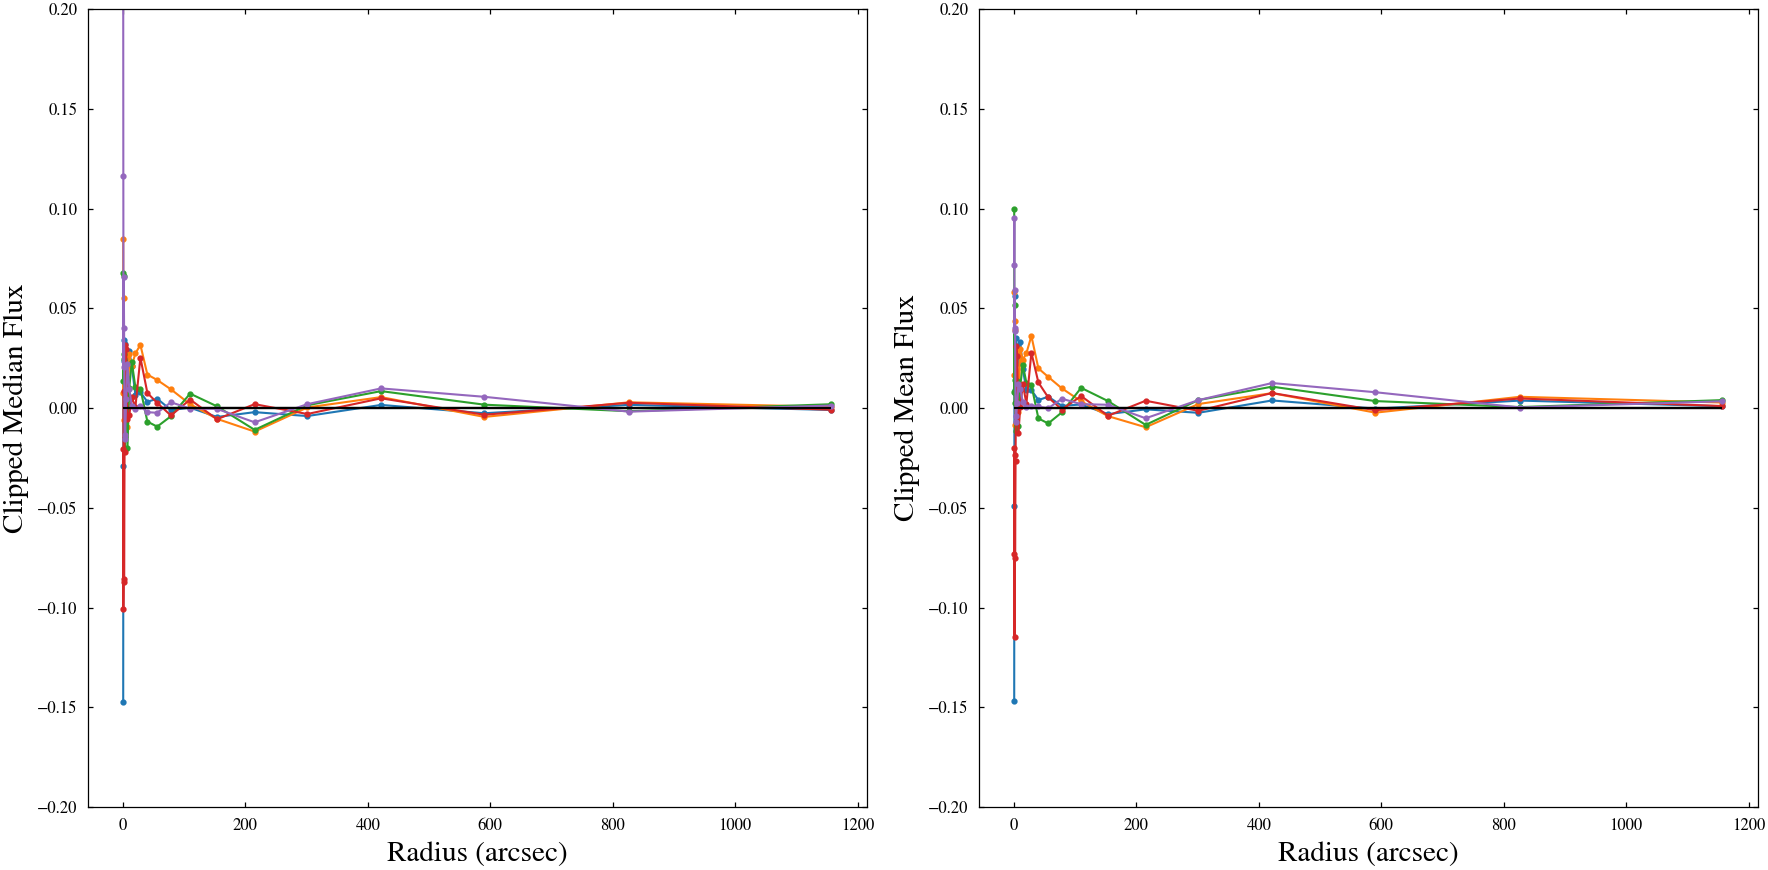

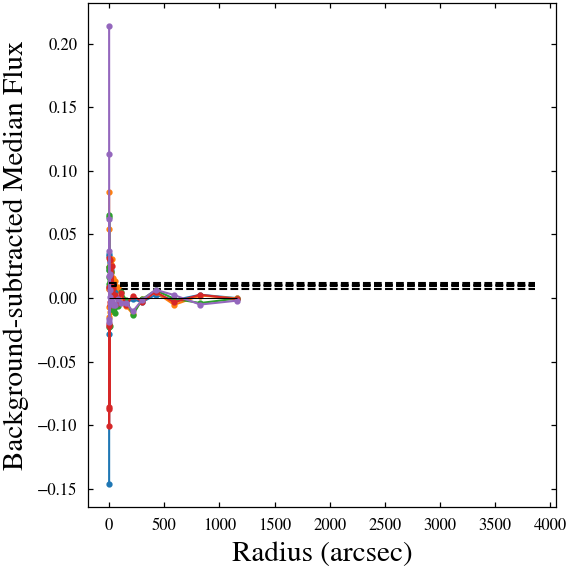

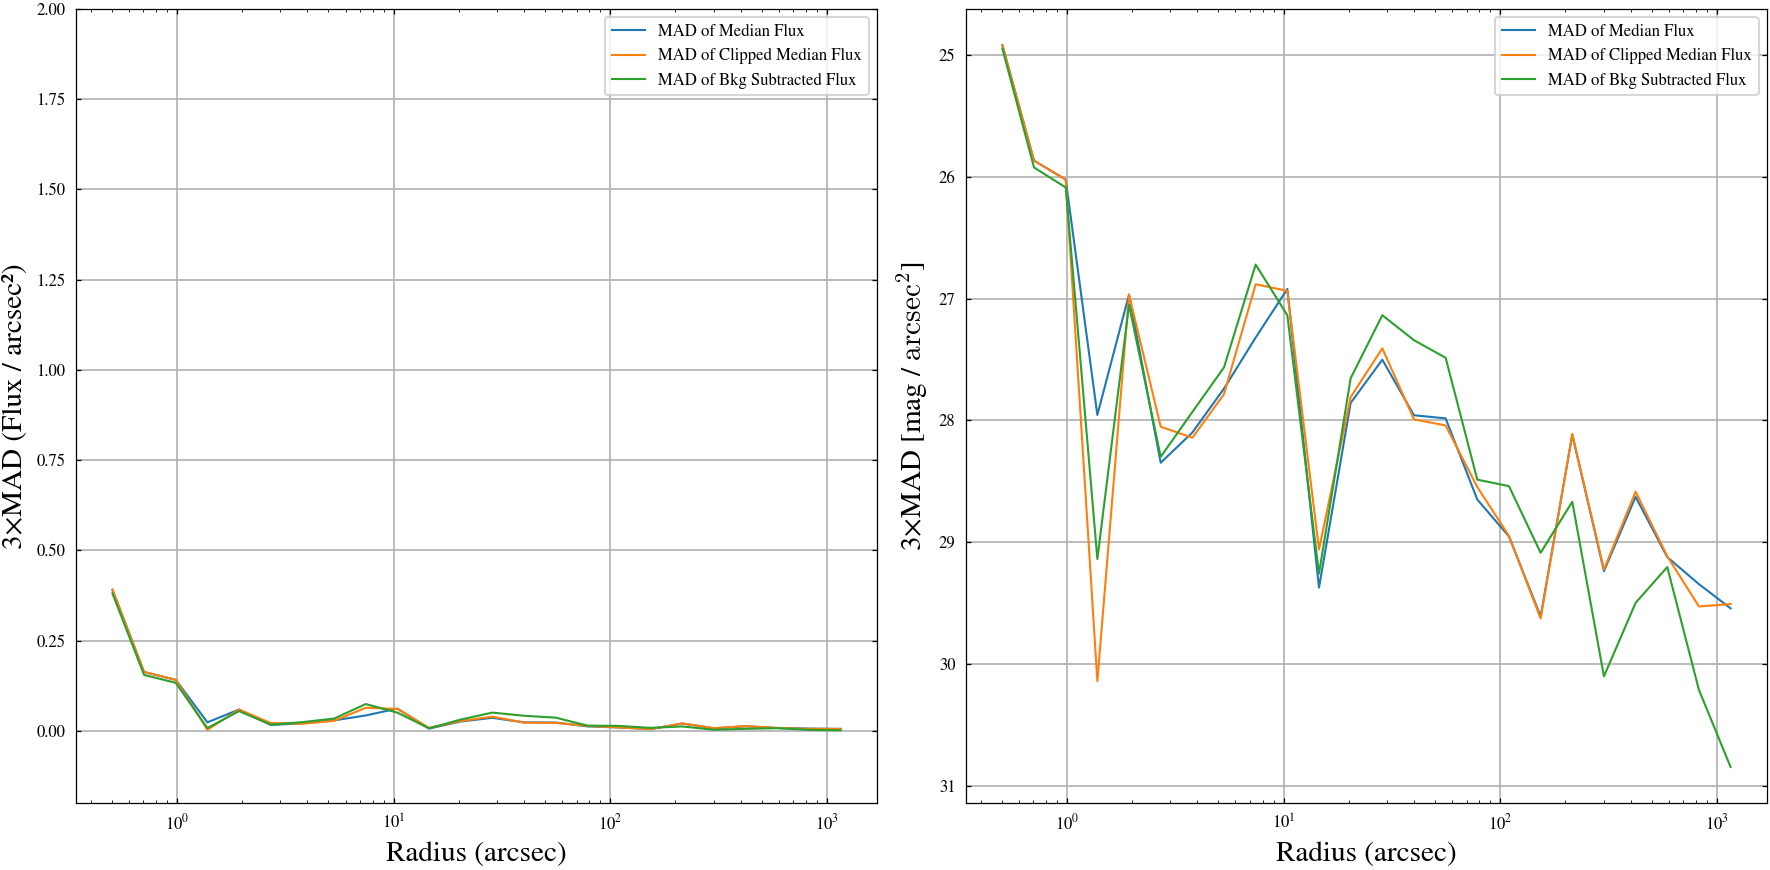

Finished plotting noise diagnostics.
Cleaned up temp file: /home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/temp_cleaned/Skypatch_Y_bkgsub.fits


In [68]:
dataDir = Path('/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/sky_patch/')
outputDir = Path('/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/')
tempDir = outputDir / 'temp_cleaned'

image_paths = {
    "H": dataDir / 'EUC_NIR_W-STK_H-sky_patch.fits',
    "J": dataDir / 'EUC_NIR_W-STK_J-sky_patch.fits',
    "Y": dataDir / 'EUC_NIR_W-STK_Y-sky_patch.fits',
}

measurement_mask = outputDir / 'Skypatch_NIR_measurement_mask.fits'
profileDir = Path('/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/')

for band in ["H", "J", "Y"]:
    print(f"Processing band {band}")

    # Create background in output directory and background-subtracted images in temp directory
    cleaned_paths = create_bkgsub_images(
        image_paths={band: image_paths[band]},
        measurement_mask_path=measurement_mask,
        output_background_dir=outputDir,
        temp_cleaned_dir=tempDir,
        label=f"Skypatch_{band}"
    )
    
    cleaned_image_path = cleaned_paths[band]

    prof_path = profileDir / f'cluster_H_random_field_growth_0.25.prof'
    verbose = f'Skypatch_{band}'

    # Measure noise on background subtracted image
    extended_measurement_table, noise_measurements, label = measure_noise_in_circular_annuli(
        image_path=cleaned_image_path,
        object_mask_path=measurement_mask,
        profile_path=prof_path,
        hdul_index=0,
        pixelscale=0.3,
        num_points=5,
        output_path=outputDir,
        verbose=verbose,
        show_annuli=False,
        show_diagnostic_plots=True,
        save_diagnostics=False
    )

    # Delete temp files
    Path(cleaned_image_path).unlink()
    print(f"Cleaned up temp file: {cleaned_image_path}")


# Processing Skypatch to extract nopoise in 5 bands

In [ ]:
profileDir = Path('/home/ppztk1/Erosita/Outputs_Clusters/cluster/autoprof_results/')
outputDir = Path('/home/ppztk1/Erosita/Outputs_Clusters/background_skypatch/')
dataDir = Path('/home/ppztk1/euclid_data/Q1_R1_clusters_v0.7/sky_patch/')
tempDir = outputDir / 'temp_cleaned'
tempDir.mkdir(exist_ok=True)

# input image files
image_paths = {
    "H": dataDir / 'EUC_NIR_W-STK_H-sky_patch.fits',
    "J": dataDir / 'EUC_NIR_W-STK_J-sky_patch.fits',
    "Y": dataDir / 'EUC_NIR_W-STK_Y-sky_patch.fits',
}
VIS_image = dataDir / 'EUC_VIS_SWL-STK-sky_patch.fits'
YJH_image = outputDir / 'Skypatch_NIR_YJH_COADDED.fits'

# mask files
nir_mask_path = outputDir / 'Skypatch_NIR_measurement_mask.fits'
vis_mask_path = outputDir / 'Skypatch_VIS_measurement_mask.fits'

# Creating NIR masks if missing
if not nir_mask_path.exists():
    bkg_mask, meas_mask, combined_im = create_combined_nir_mask(
        str(image_paths["H"]), str(image_paths["J"]), str(image_paths["Y"]),
        centre_pos=False, label='Skypatch', output_dir=str(outputDir)
    )
    print('Created NIR masks!')
else:
    print('NIR masks already exist. Skipping creation.')

# Creating VIS masks if missing
if not vis_mask_path.exists():
    bkg_mask_vis, meas_mask_vis = create_vis_mask(
        str(VIS_image), centre_pos=False, label='Skypatch', output_dir=str(outputDir)
    )
    print('Created VIS masks!')
else:
    print('VIS masks already exist. Skipping creation.')


# Processing NIR bands (H, J, Y)
nir_mask = nir_mask_path
for band in ["H", "J", "Y"]:
    print(f"\nProcessing NIR band {band}")

    cleaned_paths = create_bkgsub_images(
        image_paths={band: image_paths[band]},
        measurement_mask_path=nir_mask,
        output_background_dir=outputDir,
        temp_cleaned_dir=tempDir,
        label=f"Skypatch_{band}"
    )

    cleaned_image_path = cleaned_paths[band]
    prof_path = profileDir / f'cluster_H_random_field_growth_0.25.prof'  # Adjust if needed

    extended_measurement_table, noise_measurements, label = measure_noise_in_circular_annuli(
        image_path=cleaned_image_path,
        object_mask_path=nir_mask,
        profile_path=prof_path,
        hdul_index=0,
        pixelscale=0.3,
        num_points=5,
        output_path=outputDir,
        verbose=f'Skypatch_{band}',
        show_annuli=False,
        show_diagnostic_plots=True,
        save_diagnostics=False
    )

    Path(cleaned_image_path).unlink()
    print(f"Cleaned up temp file: {cleaned_image_path}")

# Processing YJH Coadded
print("\nProcessing NIR YJH Coadded")

cleaned_paths = create_bkgsub_images(
    image_paths={"YJH": YJH_image},
    measurement_mask_path=nir_mask,
    output_background_dir=outputDir,
    temp_cleaned_dir=tempDir,
    label="Skypatch_YJH"
)

cleaned_image_path = cleaned_paths["YJH"]

extended_measurement_table, noise_measurements, label = measure_noise_in_circular_annuli(
    image_path=cleaned_image_path,
    object_mask_path=nir_mask,
    profile_path=prof_path,
    hdul_index=0,
    pixelscale=0.3,
    num_points=5,
    output_path=outputDir,
    verbose='Skypatch_YJH',
    show_annuli=False,
    show_diagnostic_plots=True,
    save_diagnostics=False
)

Path(cleaned_image_path).unlink()
print(f"Cleaned up temp file: {cleaned_image_path}")

# Processing VIS band 
print("\nProcessing VIS image")

cleaned_paths = create_bkgsub_images(
    image_paths={"VIS": VIS_image},
    measurement_mask_path=vis_mask_path,
    output_background_dir=outputDir,
    temp_cleaned_dir=tempDir,
    label="Skypatch_VIS"
)

cleaned_image_path = cleaned_paths["VIS"]

extended_measurement_table, noise_measurements, label = measure_noise_in_circular_annuli(
    image_path=cleaned_image_path,
    object_mask_path=vis_mask_path,
    profile_path=prof_path,
    hdul_index=0,
    pixelscale=0.3,  # VIS pixel scale if different
    num_points=5,
    output_path=outputDir,
    verbose='Skypatch_VIS',
    show_annuli=False,
    show_diagnostic_plots=True,
    save_diagnostics=False
)

Path(cleaned_image_path).unlink()
print(f"Cleaned up temp file: {cleaned_image_path}")
